# Notebook 3: Training the Neural Surrogate

This notebook runs a complete training experiment on the birth-death CRN.

## What this covers

1. **Data generation** — M=16 SSA trajectories per item so variance loss has signal.
2. **Model setup** — `SDEConfig.from_crn()` sets `n_noise_channels = n_reactions`.
3. **Loss** — `CombinedTrajectoryLoss` (mean-matching + variance-matching).
4. **Training** — single call to `Trainer.train()` returns a `TrainingResult`.
5. **Evaluation** — checking that predicted mean and variance match Gillespie ground truth.

## Note on scale

Settings are deliberately small (30 epochs, 60 train items, small model) for notebook speed.
For a real run increase `N_TRAIN`, `max_epochs`, and `d_model`.

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({'figure.dpi': 100, 'font.size': 11})
torch.manual_seed(42)
np.random.seed(42)

## 1. Hyperparameters

In [2]:
from crn_surrogate.configs.model_config import ModelConfig, EncoderConfig, SDEConfig
from crn_surrogate.configs.training_config import TrainingConfig, SchedulerType
from crn_surrogate.crn.examples import birth_death

crn = birth_death(k_birth=2.0, k_death=0.5)   # stationary mean = variance = 4

model_config = ModelConfig(
    encoder=EncoderConfig(d_model=32, n_layers=2),
    # from_crn sets n_noise_channels = n_reactions = 2
    sde=SDEConfig.from_crn(crn, d_model=32, d_hidden=64, clip_state=True),
)

train_config = TrainingConfig(
    lr=3e-3,
    max_epochs=30,
    batch_size=4,
    n_sde_samples=8,
    n_ssa_samples=16,
    dt=0.2,
    val_every=5,
    grad_clip_norm=1.0,
    scheduler_type=SchedulerType.REDUCE_ON_PLATEAU,
    use_wandb=True,
    wandb_project="crn_surrogate",
    wandb_run_name="birth_death_test",
)

print(model_config)
print(train_config)

ModelConfig(encoder=EncoderConfig(d_model=32, n_layers=2, n_propensity_types=4, max_propensity_params=4), sde=SDEConfig(d_model=32, d_hidden=64, n_noise_channels=2, clip_state=True))
TrainingConfig(lr=0.003, max_epochs=30, batch_size=4, dt=0.2, n_ssa_samples=16, scheduler=reduce_on_plateau, use_wandb=True)


## 2. Generate Training and Validation Data

Each item holds M=16 independent SSA trajectories. The variance-matching loss computes
`Var_true[X(t)]` from these M runs, giving G_theta a gradient signal to learn stochasticity.

Train: 60 items x 16 SSA runs = 960 trajectories
Val:   20 items x 16 SSA runs = 320 trajectories


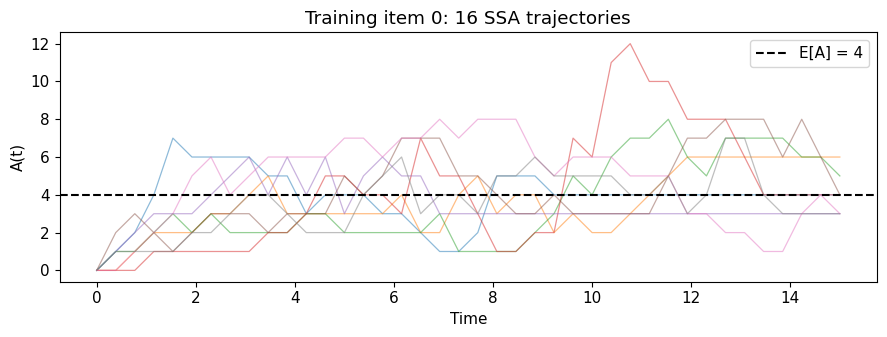

In [3]:
from crn_surrogate.simulation import GillespieSSA, interpolate_to_grid
from crn_surrogate.encoder.tensor_repr import crn_to_tensor_repr
from crn_surrogate.data.dataset import CRNTrajectoryDataset, TrajectoryItem

T_MAX = 15.0
N_GRID = 40
M = train_config.n_ssa_samples
time_grid = torch.linspace(0.0, T_MAX, N_GRID)
ssa = GillespieSSA()
init_state = torch.tensor([0.0])
crn_repr = crn_to_tensor_repr(crn)

N_TRAIN, N_VAL = 60, 20

def make_items(n):
    items = []
    for _ in range(n):
        multi = torch.stack([
            interpolate_to_grid(
                ssa.simulate(
                    stoichiometry=crn.stoichiometry_matrix,
                    propensity_fn=crn.evaluate_propensities,
                    initial_state=init_state.clone(),
                    t_max=T_MAX,
                ).times,
                ssa.simulate(
                    stoichiometry=crn.stoichiometry_matrix,
                    propensity_fn=crn.evaluate_propensities,
                    initial_state=init_state.clone(),
                    t_max=T_MAX,
                ).states,
                time_grid,
            )
            for _ in range(M)
        ])
        items.append(TrajectoryItem(
            crn_repr=crn_repr,
            initial_state=init_state.clone(),
            trajectories=multi,
            times=time_grid,
        ))
    return items

train_dataset = CRNTrajectoryDataset(make_items(N_TRAIN))
val_dataset   = CRNTrajectoryDataset(make_items(N_VAL))

print(f'Train: {len(train_dataset)} items x {M} SSA runs = {len(train_dataset)*M} trajectories')
print(f'Val:   {len(val_dataset)} items x {M} SSA runs = {len(val_dataset)*M} trajectories')

fig, ax = plt.subplots(figsize=(9, 3.5))
item = train_dataset[0]
for m in range(min(8, M)):
    ax.plot(time_grid.numpy(), item.trajectories[m, :, 0].numpy(), alpha=0.5, linewidth=0.9)
ax.axhline(2.0 / 0.5, color='black', linestyle='--', linewidth=1.5, label='E[A] = 4')
ax.set_xlabel('Time'); ax.set_ylabel('A(t)')
ax.set_title(f'Training item 0: {M} SSA trajectories')
ax.legend(); plt.tight_layout(); plt.show()

## 3. Build the Model

In [4]:
from crn_surrogate.encoder.bipartite_gnn import BipartiteGNNEncoder
from crn_surrogate.simulator.neural_sde import CRNNeuralSDE

encoder = BipartiteGNNEncoder(model_config.encoder)
sde     = CRNNeuralSDE(model_config.sde, n_species=1)

n_enc = sum(p.numel() for p in encoder.parameters())
n_sde = sum(p.numel() for p in sde.parameters())
print(f'Encoder params:  {n_enc:,}')
print(f'SDE params:      {n_sde:,}')
print(f'n_noise_channels = {model_config.sde.n_noise_channels}  (= n_reactions = {crn.n_reactions})')

Encoder params:  11,384
SDE params:      9,161
n_noise_channels = 2  (= n_reactions = 2)


## 4. Train

`CombinedTrajectoryLoss` combines:
- `MeanMatchingLoss` — trains the drift to reproduce the mean trajectory
- `VarianceMatchingLoss` — trains the diffusion to reproduce the variance

The Trainer iterates over all items in each batch, uses ReduceLROnPlateau,
and returns a `TrainingResult` for plotting.

In [5]:
from crn_surrogate.training.losses import CombinedTrajectoryLoss
from crn_surrogate.training.trainer import Trainer

loss_fn = CombinedTrajectoryLoss(var_weight=0.5)
trainer = Trainer(encoder, sde, model_config, train_config, loss_fn=loss_fn)

result = trainer.train(train_dataset, val_dataset)

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/jan/.netrc.
wandb: Currently logged in as: jan-mikelson (jan-mikelson-independent) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Epoch    1 | train=4.7984


Epoch    2 | train=0.9335


Epoch    3 | train=0.9064


Epoch    4 | train=1.1933


...

Epoch   27 | train=0.7192


Epoch   28 | train=0.7052


Epoch   29 | train=0.7054


Epoch   30 | train=0.7283 | val=0.6879


epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
timing/backward_mean_s,▃▂▂▂▆▅▃▂▂▃▃▂▃▁▁▂▂▄▁▂▂▃█▂▁▁▄▃▂▂
timing/backward_total_s,▃▂▂▂▆▅▃▂▂▃▃▂▃▁▁▂▂▄▁▂▂▃█▂▁▁▄▃▂▂
timing/forward_mean_s,▂▂▂▂▃▄▂▂▃▂▃▂▂▁▁▂▂▃▂▂▂▃█▂▁▁▃▃▂▂
timing/forward_total_s,▂▂▂▂▃▄▂▂▃▂▃▂▂▁▁▂▂▃▂▂▂▃█▂▁▁▃▃▂▂
train_loss,█▁▁▂▁▁▁▁▁▁▁▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_loss,▅▃█▁▂▅
epoch,30
timing/backward_mean_s,1.33457
timing/backward_total_s,20.01849
timing/forward_mean_s,0.86956


## 4b. Profiler Output & Optional W&B Logging

The `Trainer` records `forward` and `backward` wall-clock times for every batch using
`PhaseTimer` and writes two CSV files to `TrainingConfig.log_dir` (default `"logs/"`):

| File | Contents |
|------|----------|
| `profiler_batches.csv` | One row per batch: `forward_s`, `backward_s`, GPU memory |
| `profiler_epochs.csv` | Per-phase stats per epoch: mean / std / min / max / total |

To enable **Weights & Biases** logging, pass `use_wandb=True` to `TrainingConfig`:

```python
train_config = TrainingConfig(
    ...,
    use_wandb=True,
    wandb_project="my-project",
    wandb_run_name="run-01",
)
```

This requires `pip install wandb` and a prior `wandb login`.

In [6]:
import os, pandas as pd

batch_csv = os.path.join(train_config.log_dir, "profiler_batches.csv")
epoch_csv = os.path.join(train_config.log_dir, "profiler_epochs.csv")

if os.path.exists(batch_csv):
    df_batches = pd.read_csv(batch_csv)
    print("=== profiler_batches.csv (last 5 rows) ===")
    print(df_batches.tail())
else:
    print(f"Not found: {batch_csv}")

if os.path.exists(epoch_csv):
    df_epochs = pd.read_csv(epoch_csv)
    print("\n=== profiler_epochs.csv (last 10 rows) ===")
    print(df_epochs.tail(10))
else:
    print(f"Not found: {epoch_csv}")

=== profiler_batches.csv (last 5 rows) ===
     epoch  n_batches   forward  backward
895     30         10  0.829432  1.339046
896     30         11  0.814435  1.288542
897     30         12  0.830063  1.291912
898     30         13  0.965447  1.296568
899     30         14  0.839094  1.356975

=== profiler_epochs.csv (last 10 rows) ===
     epoch     phase    mean_s     std_s     min_s     max_s    total_s   n
110     26   forward  0.795698  0.196339  0.553805  1.472663  11.935477  15
111     26  backward  1.301249  0.397705  0.932473  2.370920  19.518742  15
112     27   forward  1.049479  0.311078  0.712492  1.967604  15.742192  15
113     27  backward  1.690172  0.536118  1.155082  2.866776  25.352584  15
114     28   forward  1.104641  0.429854  0.814875  2.557015  16.569619  15
115     28  backward  1.611225  0.411938  1.311255  2.703977  24.168382  15
116     29   forward  0.865947  0.080690  0.764704  1.010752  12.989211  15
117     29  backward  1.371657  0.130725  1.270156  1

## 5. Training Curves

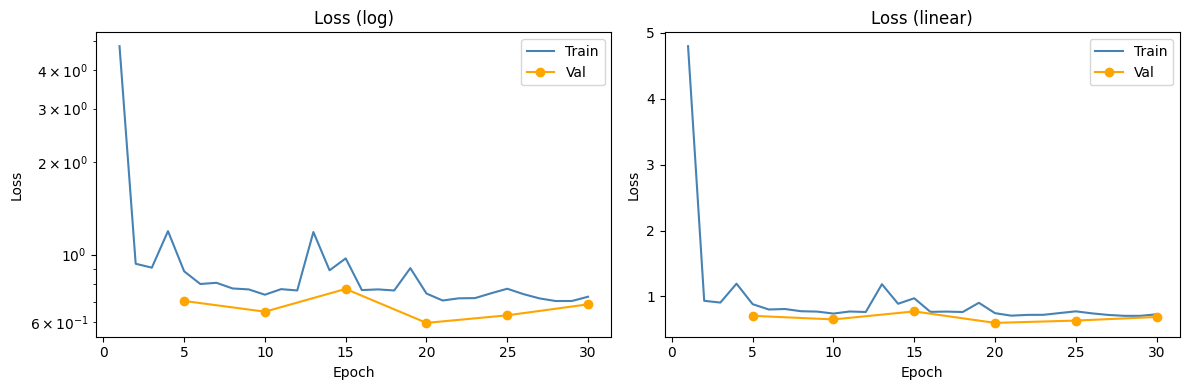

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, yscale in zip(axes, ['log', 'linear']):
    ax.plot(range(1, len(result.train_losses)+1), result.train_losses,
            label='Train', color='steelblue')
    ax.plot(result.val_epochs, result.val_losses,
            'o-', label='Val', color='orange', markersize=6)
    ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
    ax.set_title(f'Loss ({yscale})')
    ax.set_yscale(yscale); ax.legend()

plt.tight_layout(); plt.show()

## 6. Post-Training Evaluation

In [ ]:
from crn_surrogate.simulator.sde_solver import EulerMaruyamaSolver

encoder.eval(); sde.eval()
solver = EulerMaruyamaSolver(model_config.sde)

eval_init = torch.tensor([0.0])
eval_t    = torch.linspace(0.0, T_MAX, N_GRID)

with torch.no_grad():
    ctx = encoder(crn_repr, eval_init)

K_EVAL = 50
with torch.no_grad():
    sde_trajs = torch.stack([
        solver.solve(sde, eval_init.clone(), ctx, eval_t, dt=0.1).states
        for _ in range(K_EVAL)
    ])

M_EVAL = 50
ssa_trajs = torch.stack([
    interpolate_to_grid(
        ssa.simulate(
            stoichiometry=crn.stoichiometry_matrix,
            propensity_fn=crn.evaluate_propensities,
            initial_state=eval_init.clone(),
            t_max=T_MAX,
        ).times,
        ssa.simulate(
            stoichiometry=crn.stoichiometry_matrix,
            propensity_fn=crn.evaluate_propensities,
            initial_state=eval_init.clone(),
            t_max=T_MAX,
        ).states,
        eval_t,
    )
    for _ in range(M_EVAL)
])

print(f'Neural SDE: {sde_trajs.shape}, Gillespie: {ssa_trajs.shape}')

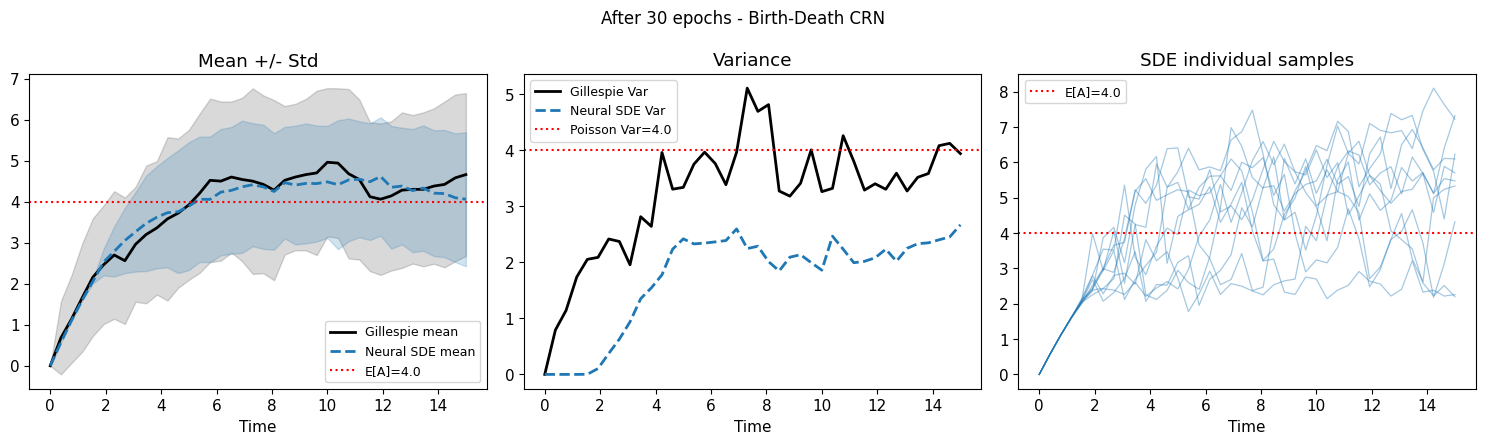

In [9]:
t = eval_t.numpy()
sde_mean = sde_trajs[:, :, 0].mean(dim=0).numpy()
sde_std  = sde_trajs[:, :, 0].std(dim=0).numpy()
ssa_mean = ssa_trajs[:, :, 0].mean(dim=0).numpy()
ssa_std  = ssa_trajs[:, :, 0].std(dim=0).numpy()
true_mean = 2.0 / 0.5

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

ax = axes[0]
ax.plot(t, ssa_mean, 'k-', lw=2, label='Gillespie mean')
ax.fill_between(t, ssa_mean-ssa_std, ssa_mean+ssa_std, alpha=0.15, color='black')
ax.plot(t, sde_mean, '--', color='tab:blue', lw=2, label='Neural SDE mean')
ax.fill_between(t, sde_mean-sde_std, sde_mean+sde_std, alpha=0.2, color='tab:blue')
ax.axhline(true_mean, color='red', linestyle=':', lw=1.5, label=f'E[A]={true_mean}')
ax.set_title('Mean +/- Std'); ax.set_xlabel('Time'); ax.legend(fontsize=9)

ax = axes[1]
ax.plot(t, ssa_std**2, 'k-', lw=2, label='Gillespie Var')
ax.plot(t, sde_std**2, '--', color='tab:blue', lw=2, label='Neural SDE Var')
ax.axhline(true_mean, color='red', linestyle=':', lw=1.5, label=f'Poisson Var={true_mean}')
ax.set_title('Variance'); ax.set_xlabel('Time'); ax.legend(fontsize=9)

ax = axes[2]
for k in range(min(10, K_EVAL)):
    ax.plot(t, sde_trajs[k, :, 0].numpy(), alpha=0.4, lw=0.9, color='tab:blue')
ax.axhline(true_mean, color='red', linestyle=':', lw=1.5, label=f'E[A]={true_mean}')
ax.set_title('SDE individual samples'); ax.set_xlabel('Time'); ax.legend(fontsize=9)

plt.suptitle(f'After {train_config.max_epochs} epochs - Birth-Death CRN', fontsize=12)
plt.tight_layout(); plt.show()

In [10]:
sde_final_mean = float(sde_trajs[:, -10:, 0].mean())
ssa_final_mean = float(ssa_trajs[:, -10:, 0].mean())
sde_final_var  = float(sde_trajs[:, -10:, 0].var())
ssa_final_var  = float(ssa_trajs[:, -10:, 0].var())
sde_cv = float(sde_trajs[:, :, 0].std(dim=0).mean())

mean_mse = float(((torch.tensor(sde_mean) - torch.tensor(ssa_mean))**2).mean())
var_mse  = float(((torch.tensor(sde_std**2) - torch.tensor(ssa_std**2))**2).mean())

print('=' * 54)
print(f'Mean trajectory MSE:   {mean_mse:.4f}')
print(f'Variance MSE:          {var_mse:.4f}')
print()
print(f'Converged mean  - SDE: {sde_final_mean:.2f} | SSA: {ssa_final_mean:.2f} | Analytical: {true_mean:.2f}')
print(f'Converged var   - SDE: {sde_final_var:.2f}  | SSA: {ssa_final_var:.2f}  | Analytical: {true_mean:.2f}')
print()
print(f'Mean SDE std (stochasticity check): {sde_cv:.3f}')
stochastic = sde_cv >= 0.1
print('  OK - diffusion is nonzero' if stochastic else '  WARNING - diffusion may not have learned')
print('=' * 54)

Mean trajectory MSE:   0.0714
Variance MSE:          2.5012

Converged mean  - SDE: 4.30 | SSA: 4.32 | Analytical: 4.00
Converged var   - SDE: 2.27  | SSA: 3.58  | Analytical: 4.00

Mean SDE std (stochasticity check): 1.209
  OK - diffusion is nonzero
